# Task1 - Environment Setup & Data Loading

In [631]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import os
os.chdir('/Users/jaeeunlee/data-practice')

drivers = pd.read_csv("data/drivers.csv")
races = pd.read_csv("data/races.csv")
results = pd.read_csv("data/results.csv")
constructors = pd.read_csv("data/constructors.csv")
circuits = pd.read_csv("data/circuits.csv")

dataframes = {
    "drivers": drivers,
    "races": races,
    "results": results,
    "constructors": constructors,
    "circuits": circuits
}


# Display the shape and data types of each dataframe
for name, df in dataframes.items():
    print("=" * 50)
    print(f"{name.upper()}")
    print(f"Shape: {df.shape}\n")
    print("Data Types:")
    print(df.dtypes)
    print("\n")


# Display the shape and data types of each dataframe
for name, df in dataframes.items():
    print("=" * 50)
    print(f"{name.upper()}")
    print(f"Shape: {df.shape}\n")
    print("Data Types:")
    print(df.dtypes)
    print("\n")

DRIVERS
Shape: (861, 9)

Data Types:
driverId       int64
driverRef        str
number           str
code             str
forename         str
surname          str
dob              str
nationality      str
url              str
dtype: object


RACES
Shape: (1125, 18)

Data Types:
raceId         int64
year           int64
round          int64
circuitId      int64
name             str
date             str
time             str
url              str
fp1_date         str
fp1_time         str
fp2_date         str
fp2_time         str
fp3_date         str
fp3_time         str
quali_date       str
quali_time       str
sprint_date      str
sprint_time      str
dtype: object


RESULTS
Shape: (26759, 18)

Data Types:
resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number                 str
grid                 int64
position               str
positionText           str
positionOrder        int64
points             float64
laps             

# Task2 - Data Cleaning

In [632]:
# 1. results.csv 
results_cols = ['milliseconds', 'fastestLapTime', 'fastestLapSpeed']

print("=== results.csv ===")
print(f"Total rows: {len(results)}\n")

for col in results_cols:
    n_missing = (results[col].astype(str) == '\\N').sum()
    pct = n_missing / len(results) * 100
    print(f"{col}: {n_missing} missing ({pct:.2f}%)")

before = pd.DataFrame({
    "Before": results[results_cols].isna().sum()
})
results.head(15)

# 2. drivers.csv
drivers_cols = ['dob', 'nationality']

print("\n=== drivers.csv ===")
print(f"Total rows: {len(drivers)}\n")

for col in drivers_cols:
    n_missing = (drivers[col].astype(str) == '\\N').sum()
    pct = n_missing / len(drivers) * 100
    print(f"{col}: {n_missing} missing ({pct:.2f}%)")


=== results.csv ===
Total rows: 26759

milliseconds: 19079 missing (71.30%)
fastestLapTime: 18507 missing (69.16%)
fastestLapSpeed: 18507 missing (69.16%)

=== drivers.csv ===
Total rows: 861

dob: 0 missing (0.00%)
nationality: 0 missing (0.00%)


### additional note - why results.csv has so many missing values?

#### 1. a lack of record from the past

In [633]:
# Merge to bring in the 'year' column
results = results.merge(races[['raceId', 'year']], on='raceId', how='left')

# Split into pre-2000s and post-2000s (2000 onward)
pre_2000 = results[results['year'] < 2000]
post_2000 = results[results['year'] >= 2000]

def missing_pct(df, col):
    n_missing = (df[col].astype(str) == '\\N').sum()
    return n_missing / len(df) * 100

cols = ['milliseconds', 'fastestLapTime', 'fastestLapSpeed']

print(f"Pre-2000 rows: {len(pre_2000)}")
print(f"Post-2000 rows: {len(post_2000)}\n")

print(f"{'Column':<18}{'Pre-2000 missing %':<22}{'Post-2000 missing %'}")
for col in cols:
    pre_pct = missing_pct(pre_2000, col)
    post_pct = missing_pct(post_2000, col)
    print(f"{col:<18}{pre_pct:<22.2f}{post_pct:.2f}")


Pre-2000 rows: 16680
Post-2000 rows: 10079

Column            Pre-2000 missing %    Post-2000 missing %
milliseconds      82.15                 53.34
fastestLapTime    100.00                18.13
fastestLapSpeed   100.00                18.13


#### 2. a result of DNF

In [634]:
cols = ['milliseconds', 'fastestLapTime', 'fastestLapSpeed']

for col in cols:
    missing_mask = results[col].astype(str) == '\\N'
    n_missing = missing_mask.sum()
    
    # Among the missing rows, how many are DNF (positionText == 'R')?
    n_dnf_in_missing = (results.loc[missing_mask, 'positionText'] == 'R').sum()
    dnf_ratio = n_dnf_in_missing / n_missing * 100 if n_missing > 0 else 0
    
    print(f"=== {col} ===")
    print(f"Total missing: {n_missing}")
    print(f"Missing rows that are DNF (positionText == 'R'): {n_dnf_in_missing}")
    print(f"DNF ratio among missing: {dnf_ratio:.2f}%\n")

=== milliseconds ===
Total missing: 19079
Missing rows that are DNF (positionText == 'R'): 8897
DNF ratio among missing: 46.63%

=== fastestLapTime ===
Total missing: 18507
Missing rows that are DNF (positionText == 'R'): 7704
DNF ratio among missing: 41.63%

=== fastestLapSpeed ===
Total missing: 18507
Missing rows that are DNF (positionText == 'R'): 7704
DNF ratio among missing: 41.63%



As you can see, the missing values in results.csv are highly influenced by lack of record before 2000. And high ratio of DNF caused a lot of missing values as well.


# Task3 - Merge Master Dataset

In [635]:
# Build driver full name
drivers['driverName'] = drivers['forename'] + ' ' + drivers['surname']

race_cols = ['raceId', 'round']
merged = results.merge(races[race_cols], on='raceId', how='left')

# Merge in driver names
merged = merged.merge(drivers[['driverId', 'driverName']], on='driverId', how='left')

# Merge in constructor names
merged = merged.merge(
    constructors[['constructorId', 'name']].rename(columns={'name': 'constructorName'}),
    on='constructorId', how='left'
)

# Select the required columns
final_cols = [
    'raceId', 'year', 'round', 'driverName', 'constructorName',
    'grid', 'position', 'points', 'statusId'
]

merged_f1 = merged[final_cols]

print(merged_f1.shape)
print(merged_f1.head())

# Export to CSV
merged_f1.to_csv('jaeeun/output/merged_f1.csv', index=False)

(26759, 9)
   raceId  year  round         driverName constructorName  grid position  \
0      18  2008      1     Lewis Hamilton         McLaren     1        1   
1      18  2008      1      Nick Heidfeld      BMW Sauber     5        2   
2      18  2008      1       Nico Rosberg        Williams     7        3   
3      18  2008      1    Fernando Alonso         Renault    11        4   
4      18  2008      1  Heikki Kovalainen         McLaren     3        5   

   points  statusId  
0    10.0         1  
1     8.0         1  
2     6.0         1  
3     5.0         1  
4     4.0         1  


# Task4 - Top Drivers by Career Points

In [636]:
# If results already has year, avoid merging year again
if 'year' in results.columns:
    result_races = results.copy()
else:
    result_races = results.merge(
        races[['raceId', 'year']],
        on='raceId',
        how='left'
    )

result_races = result_races[
    (result_races["year"] >= 1995) &
    (result_races["year"] <= 2020)
]

career_points = result_races.groupby('driverId', as_index=False).agg(
    Total_Points=('points', 'sum')
)

career_points = career_points.merge(
    drivers[["driverId", "forename", "surname"]],
    on="driverId",
    how="left"
)

career_points["driver"] = (
    career_points["forename"] + " " + career_points["surname"]
)

top10 = (
    career_points[["driver", "Total_Points"]]
    .sort_values("Total_Points", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10

,driver,Total_Points
0,Lewis Hamilton,3778.0
1,Sebastian Vettel,3018.0
2,Fernando Alonso,1899.0
3,Kimi Räikkönen,1863.0
4,Nico Rosberg,1594.5
5,Valtteri Bottas,1512.0
6,Michael Schumacher,1365.0
7,Jenson Button,1235.0
8,Felipe Massa,1167.0
9,Max Verstappen,1162.0


/var/folders/dr/v66_x2k55hbc5gf4xyt07q4h0000gn/T/ipykernel_50531/1625003183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


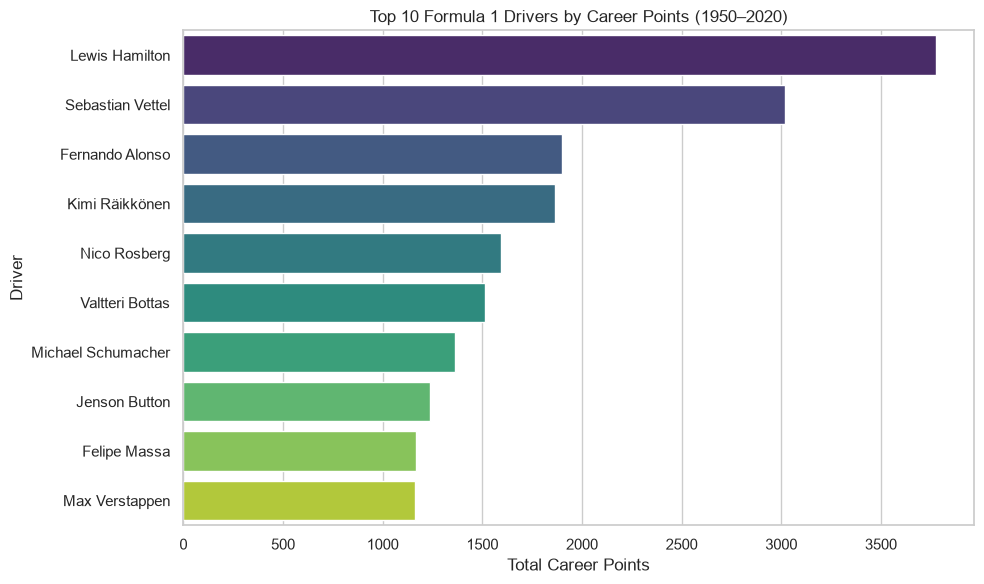

In [637]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x="Total_Points",
    y="driver",
    palette="viridis"
)

plt.title("Top 10 Formula 1 Drivers by Career Points (1950–2020)")
plt.xlabel("Total Career Points")
plt.ylabel("Driver")

plt.tight_layout()
plt.show()

# Task5 - Top Constructors by Decade

In [638]:
results_with_position = results.assign(
    position=pd.to_numeric(results["position"], errors="coerce")
)

wins = results_with_position[results_with_position["position"] == 1].copy()

if "year" not in wins.columns:
    wins = wins.merge(races[["raceId", "year"]], on="raceId", how="left")

wins = wins.merge(
    constructors[["constructorId", "name"]],
    on="constructorId",
    how="left"
)

wins["decade"] = (wins["year"] // 10 * 10).astype(int).astype(str) + "s"

wins_by_decade = (
    wins
    .groupby(["decade", "name"])
    .size()
    .reset_index(name="wins")
    .sort_values(["decade", "wins"], ascending=[True, False])
)

wins_pivot = (
    wins_by_decade
    .pivot(index="name", columns="decade", values="wins")
    .fillna(0)
    .astype(int)
)

wins_pivot

decade,1950s,1960s,1970s,1980s,1990s,2000s,2010s,2020s
name,,,,,,,,
Alfa Romeo,11,0,0,0,0,0,0,0
AlphaTauri,0,0,0,0,0,0,0,1
Alpine F1 Team,0,0,0,0,0,0,0,1
BMW Sauber,0,0,0,0,0,1,0,0
BRM,1,12,4,0,0,0,0,0
Benetton,0,0,0,2,25,0,0,0
Brabham,0,0,8,15,0,0,0,0
Brabham-Climax,0,2,0,0,0,0,0,0
Brabham-Ford,0,2,0,0,0,0,0,0


# Task6 - NumPy Statistics on Finishing Position

In [639]:
results["positionOrder"] = pd.to_numeric(results["positionOrder"], errors='coerce')

driver_names = ["Lewis Hamilton", "Michael Schumacher"]

selected = drivers.copy()
selected["driver"] = selected["forename"] + " " + selected["surname"]

selected = selected[selected["driver"].isin(driver_names)]
selected
hamilton_id = selected[selected["driver"]=="Lewis Hamilton"]["driverId"].iloc[0]
schumacher_id = selected[selected["driver"]=="Michael Schumacher"]["driverId"].iloc[0]

hamilton_pos = results.loc[
    results["driverId"] == hamilton_id,
    "positionOrder"
].to_numpy()

schumacher_pos = results.loc[
    results["driverId"] == schumacher_id,
    "positionOrder"
].to_numpy()
comparison = pd.DataFrame({
    "Driver": driver_names,
    "Mean Finish": [
        np.mean(hamilton_pos),
        np.mean(schumacher_pos)
    ],
    "Median Finish": [
        np.median(hamilton_pos),
        np.median(schumacher_pos)
    ],
    "Std Dev": [
        np.std(hamilton_pos),
        np.std(schumacher_pos)
    ]
})

comparison

,Driver,Mean Finish,Median Finish,Std Dev
0,Lewis Hamilton,5.019663,3.0,5.543207
1,Michael Schumacher,6.879870,3.0,7.061087


# Task7 - Chart 1 - Races per Season

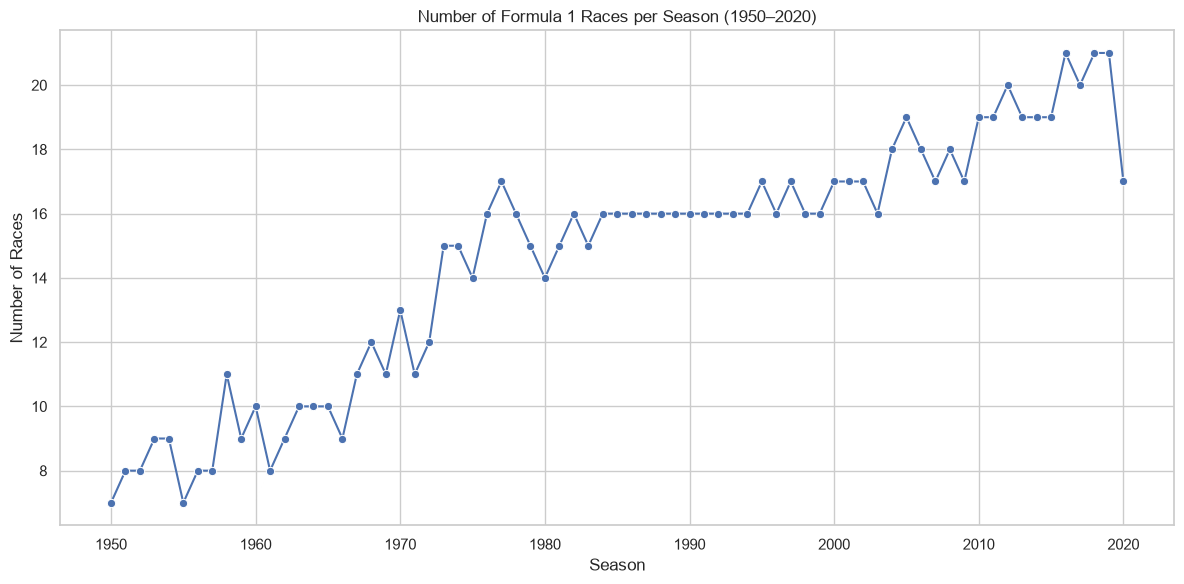

In [640]:
result_races = races[(races["year"] >= 1950) 
                            & (races["year"] <= 2020)]

result_races
num_of_races = (
    result_races
    .groupby("year")
    .size()
    .reset_index(name="num_of_races")    
)

num_of_races
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

#graph drawing
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=num_of_races,
    x="year",
    y="num_of_races",
    marker="o"
)

plt.title("Number of Formula 1 Races per Season (1950–2020)")
plt.xlabel("Season")
plt.ylabel("Number of Races")

plt.tight_layout()

# saving as png
plt.savefig("jaeeun/output/chart1_races_per_season.png", dpi=300)

plt.show()

# Task8 - Chart 2 - Top 10 Drivers by Wins

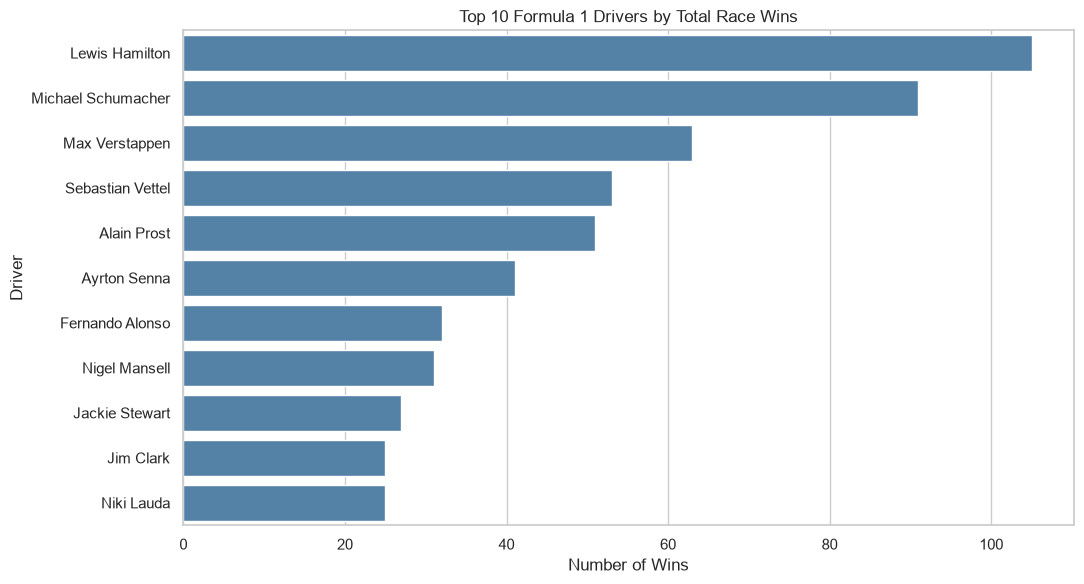

In [641]:
results_with_position = results.assign(
    position=pd.to_numeric(results["position"], errors="coerce")
)

wins_only = results_with_position[results_with_position["position"] == 1]

wins_by_driver = (
    wins_only
    .groupby("driverId")
    .size()
    .reset_index(name="wins")
    .merge(drivers[["driverId", "forename", "surname"]], on="driverId", how="left")
)

wins_by_driver["driver"] = (
    wins_by_driver["forename"] + " " + wins_by_driver["surname"]
)

top10_wins = (
    wins_by_driver[["driver", "wins"]]
    .sort_values("wins", ascending=False)
    .head(11)
    .reset_index(drop=True)
)


plt.figure(figsize=(11, 6))

sns.barplot(
    data=top10_wins,
    x="wins",
    y="driver",
    color="steelblue",   # choose any color you like
)

plt.title("Top 10 Formula 1 Drivers by Total Race Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Driver")
plt.tight_layout()
plt.savefig("jaeeun/output/chart2_top10_wins.png", dpi=300)
plt.show()

# Task9 - Chart 3 - Grid vs Finish Position

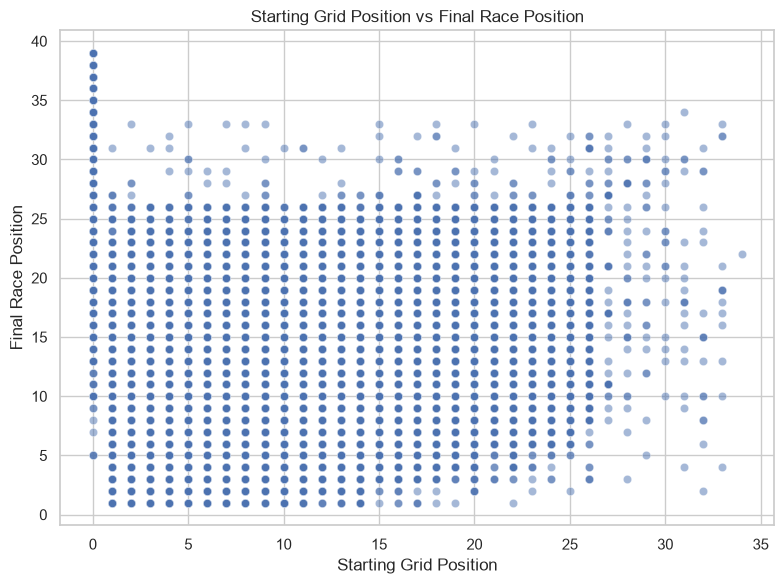

In [642]:
#copying the relevant columns for plotting
plot_data = results[["grid", "positionOrder"]].copy()

plot_data["grid"] = pd.to_numeric(plot_data["grid"], errors="coerce")
plot_data["positionOrder"] = pd.to_numeric(
    plot_data["positionOrder"],
    errors="coerce"
)

plot_data = plot_data.dropna()

# Calculate the correlation coefficient between starting grid
correlation = np.corrcoef(
    plot_data["grid"],
    plot_data["positionOrder"]
)[0, 1]

# Display the correlation coefficient
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_data,
    x="grid",
    y="positionOrder",
    alpha=0.5
)

plt.title("Starting Grid Position vs Final Race Position")
plt.xlabel("Starting Grid Position")
plt.ylabel("Final Race Position")

plt.tight_layout()

plt.savefig("jaeeun/output/chart3_grid_vs_finish.png", dpi=300)

plt.show()



### Write a short summary/report describing 3 key insights discovered from the analysis above.

### **Task 2 – Missing Values**

A detailed investigation of the missing values in `results.csv` revealed two main causes. First, many missing values are associated with **DNF (Did Not Finish)** records, where race completion statistics are unavailable. Second, before the 2000s, race timing systems were less developed, resulting in almost all values for `milliseconds`, `fastestLapTime`, and `fastestLapSpeed` being unrecorded and therefore stored as missing values. Consequently, analyses involving these variables should consider separating data from the pre-2000 and post-2000 periods to avoid biased interpretations.

---

### **Task 7 – Number of Races by Season**

The number of races per season generally increased from 1995 to 2019, reflecting the expansion of the Formula 1 calendar. However, the 2020 season shows an exceptional decline, with the number of races falling to a level similar to that of 2007 and 2009. This decrease was most likely caused by the global COVID-19 pandemic, which led to race cancellations and schedule changes.

---

### **Task 9 – Starting Grid Position**

Starting grid position is positively associated with final race position, indicating that drivers who start closer to the front are more likely to finish in higher positions. However, because the starting grid is determined by qualifying performance rather than assigned randomly, this relationship should be interpreted as an association rather than evidence of a causal effect. Driver skill, car performance, and team competitiveness are likely to influence both qualifying and race results.

# Task 11 - Driver Consistency Score

# Driver Consistency Score

Aggregates driver-season stats and combines them into a single consistency score.

**1. Per driver-season stats**
- `avg_points_per_race`, `std_points`, `race_count` (min 5 races), `DNF_Rate`

**2. Teammate-relative performance**
Within the same race/constructor, compare each driver's finish to their teammate's:

$$
\text{teammate\_diff} = \overline{\text{positionOrder}}_{\text{team}} - \text{positionOrder}_{\text{driver}}
$$

Aggregated per season as mean and std.

**3. Coefficient of variation (CV)**
Normalizes volatility by scoring level, so high scorers aren't penalized for naturally larger point swings:

$$
\text{CV}_{\text{points}} = \frac{\text{std\_points}}{\text{avg\_points\_per\_race} + 0.1}
$$

**4. Min-max normalization (within each season)**
Prevents cross-era distortion from different points systems/eras:

$$
\text{Normalized}(x) = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

**5. Weighted score**

$$
\begin{aligned}
\text{Consistency Score} =\ & 0.30 \times \text{Norm(Points)} \\
+\ & 0.20 \times (1 - \text{Norm(CV)}) \\
+\ & 0.15 \times (1 - \text{Norm(DNF Rate)}) \\
+\ & 0.20 \times \text{Norm(Teammate Diff)} \\
+\ & 0.15 \times (1 - \text{Norm(Teammate Diff Std)})
\end{aligned}
$$


**6.** Merge driver names, rank by `consistency_score` per season, print top 10.

In [643]:
if 'year' not in results.columns:
    results = results.merge(races[['raceId', 'year']], on='raceId', how='left')

# driverId + year 
consistency = results.groupby(['driverId', 'year']).agg(
    avg_points_per_race=('points', 'mean'),
    std_points=('points', 'std'),
    race_count=('raceId', 'count'),
    DNF_Rate=('statusId', lambda x: (x != 1).sum() / len(x) * 100)
).reset_index()

consistency = consistency[consistency['race_count'] >= 5]  # season unit

# teammate relative performance 
team_size = results.groupby(['raceId', 'constructorId'])['driverId'].transform('count')

results['teammate_diff'] = results.groupby(['raceId', 'constructorId'])['positionOrder']\
    .transform(lambda x: x.mean() - x)
results.loc[team_size < 2, 'teammate_diff'] = np.nan

teammate_stats = results.groupby(['driverId', 'year']).agg(
    teammate_diff_mean=('teammate_diff', 'mean'),
    teammate_diff_std=('teammate_diff', 'std')
).reset_index()

consistency = consistency.merge(teammate_stats, on=['driverId', 'year'], how='left')
consistency = consistency.dropna(subset=['teammate_diff_mean', 'teammate_diff_std'])

# CV calculation
consistency['cv_points'] = consistency['std_points'] / (consistency['avg_points_per_race'] + 0.1)

# normalizing across a season
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

consistency['norm_points']       = consistency.groupby('year')['avg_points_per_race'].transform(normalize)
consistency['norm_cv']           = consistency.groupby('year')['cv_points'].transform(normalize)
consistency['norm_dnf']          = consistency.groupby('year')['DNF_Rate'].transform(normalize)
consistency['norm_teammate']     = consistency.groupby('year')['teammate_diff_mean'].transform(normalize)
consistency['norm_teammate_std'] = consistency.groupby('year')['teammate_diff_std'].transform(normalize)

# Consistency Score 
consistency['consistency_score'] = (
    0.30 * consistency['norm_points'] +
    0.20 * (1 - consistency['norm_cv']) +
    0.15 * (1 - consistency['norm_dnf']) +
    0.20 * consistency['norm_teammate'] +
    0.15 * (1 - consistency['norm_teammate_std'])
)

# driver name merge
consistency = consistency.merge(
    drivers[['driverId', 'forename', 'surname']],
    on='driverId',
    how='left'
)
consistency['driver_name'] = consistency['forename'] + ' ' + consistency['surname']

# season-wise ranking
consistency_ranked_2019 = consistency[consistency['year'] == 2019].sort_values(
    'consistency_score', ascending=False
)[['driverId', 'driver_name', 'year', 'consistency_score']].reset_index(drop=True)


years = sorted(consistency['year'].unique())

for y in years[::-1]:
    if y==2019:
        print(f"\n===== {y}년 =====")
        display(
            consistency[consistency['year'] == y]
            .sort_values('consistency_score', ascending=False)
            [['driverId', 'driver_name', 'consistency_score']]
            .reset_index(drop=True)
            .head(10)  
        )



===== 2019년 =====


,driverId,driver_name,consistency_score
0,1,Lewis Hamilton,0.903422
1,830,Max Verstappen,0.725743
2,822,Valtteri Bottas,0.670717
3,844,Charles Leclerc,0.605406
4,20,Sebastian Vettel,0.503473
5,847,George Russell,0.496154
6,848,Alexander Albon,0.448693
7,832,Carlos Sainz,0.442950
8,815,Sergio Pérez,0.432626
9,8,Kimi Räikkönen,0.426788


# Task12 - Constructor Championship Simulation

In [644]:
# Build driver full name
drivers['driverName'] = drivers['forename'] + ' ' + drivers['surname']

race_cols = ['raceId', 'round']
merged = results.merge(races[race_cols], on='raceId', how='left')

# Merge in driver names
merged = merged.merge(drivers[['driverId', 'driverName']], on='driverId', how='left')

# Merge in constructor names
merged = merged.merge(
    constructors[['constructorId', 'name']].rename(columns={'name': 'constructorName'}),
    on='constructorId', how='left'
)

# Select the required columns
final_cols = [
    'raceId', 'year', 'round', 'driverName', 'constructorName',
    'grid', 'position', 'points', 'statusId', 'positionOrder'
]

merged_f1 = merged[final_cols]

merged_f1.to_csv('jaeeun/output/merged_f1.csv', index=False)
POINTS_SYSTEM = {
    1990: {1:9, 2:6, 3:4, 4:3, 5:2, 6:1},
    2020: {1:25, 2:18, 3:15, 4:12, 5:10, 6:8, 7:6, 8:4, 9:2, 10:1}
}
merged_f1 = pd.read_csv('jaeeun/output/merged_f1.csv')



def simulate_constructor_standings(year, points_rule):
    season = merged_f1[merged_f1['year'] == year].copy()

    season['sim_points'] = season['positionOrder'].map(points_rule).fillna(0)

    standings = (
        season
        .groupby('constructorName', as_index=False)['sim_points']
        .sum()
        .sort_values('sim_points', ascending=False)
        .reset_index(drop=True)
    )

    standings['sim_position'] = standings.index + 1

    return standings[['sim_position', 'constructorName', 'sim_points']]

simulated_1990 = simulate_constructor_standings(
    1990,
    POINTS_SYSTEM[2020]
)


#extract original data
original_1990 = (
    merged_f1[merged_f1['year'] == 1990]
    .groupby('constructorName', as_index=False)['points']
    .sum()
    .sort_values('points', ascending=False)
    .reset_index(drop=True)
)

original_1990['orig_position'] = original_1990.index + 1

original_1990 = original_1990.rename(columns={
    'constructorName': 'orig_constructor',
    'points': 'orig_points'
})[['orig_position', 'orig_constructor', 'orig_points']]

simulated_1990 = simulated_1990.rename(columns={
    'constructorName': 'sim_constructor'
})

side_by_side = pd.concat([original_1990, simulated_1990], axis=1)
side_by_side

,orig_position,orig_constructor,orig_points,sim_position,sim_constructor,sim_points
0,1,McLaren,121.0,1,McLaren,388.0
1,2,Ferrari,110.0,2,Ferrari,345.0
2,3,Benetton,71.0,3,Benetton,278.0
3,4,Williams,57.0,4,Williams,235.0
4,5,Tyrrell,16.0,5,Tyrrell,100.0
5,6,Larrousse,11.0,6,Larrousse,77.0
6,7,Leyton House,7.0,7,Team Lotus,47.0
7,8,Team Lotus,3.0,8,Leyton House,47.0
8,9,Arrows,2.0,9,Arrows,34.0
9,10,Brabham,2.0,10,Ligier,22.0


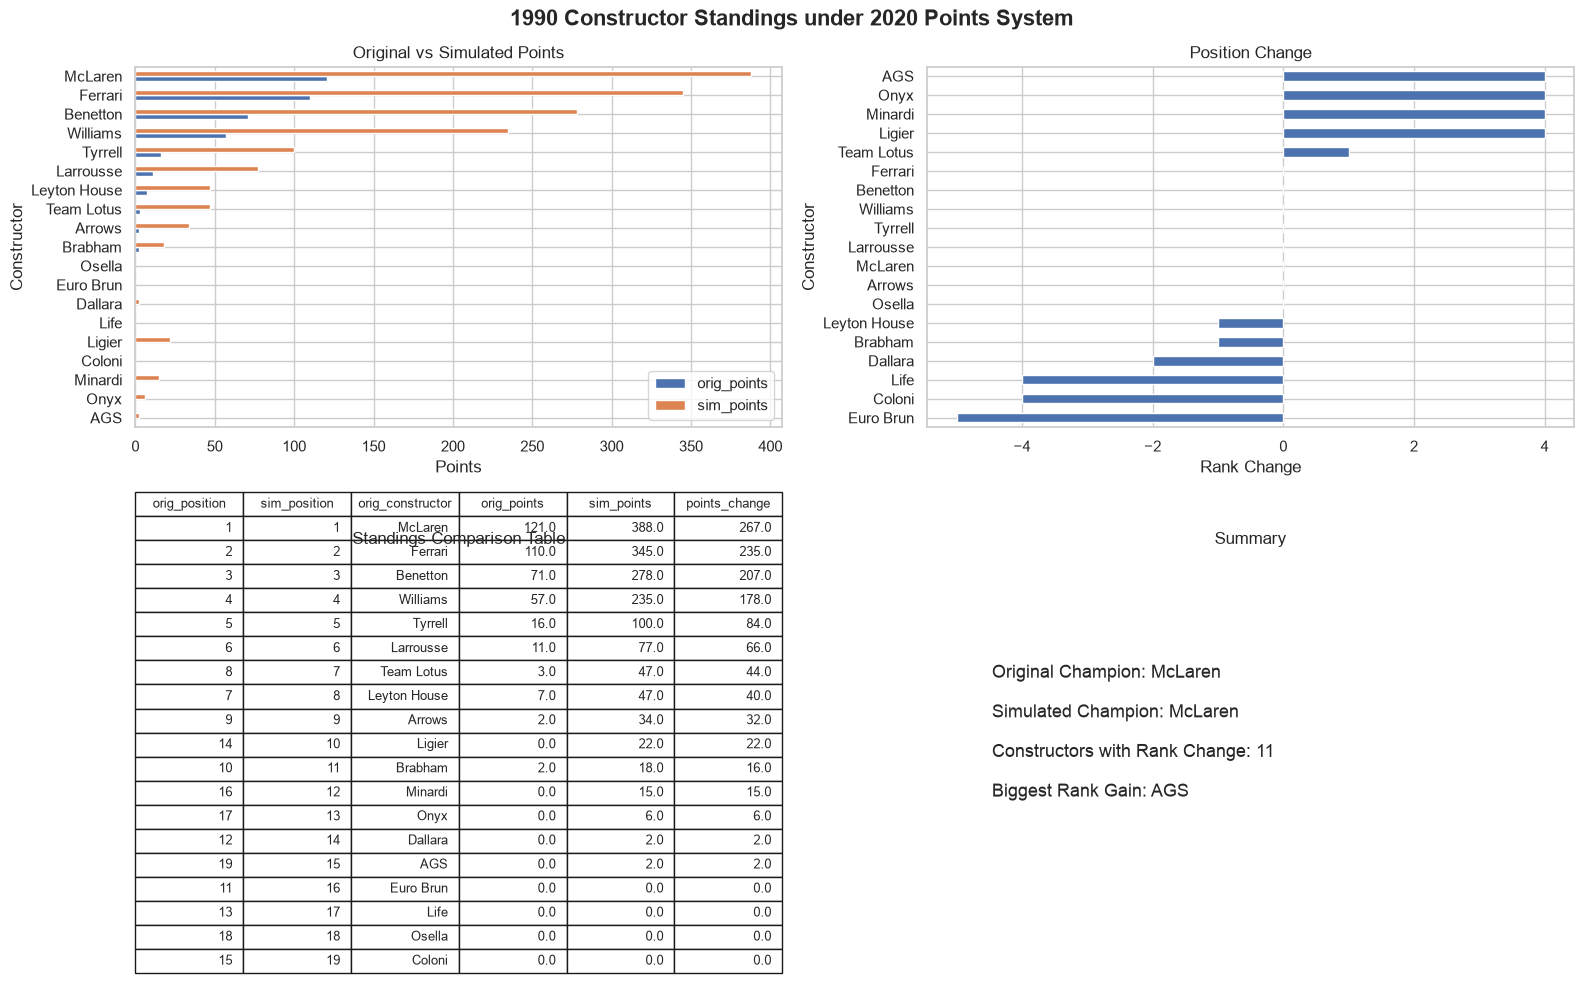

In [645]:
comparison = original_1990.merge(
    simulated_1990,
    left_on='orig_constructor',
    right_on='sim_constructor',
    how='inner'
)

comparison['position_change'] = comparison['orig_position'] - comparison['sim_position']
comparison['points_change'] = comparison['sim_points'] - comparison['orig_points']

dashboard = comparison.copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    '1990 Constructor Standings under 2020 Points System',
    fontsize=16,
    fontweight='bold'
)

# 1. Original vs Simulated Points
dashboard.sort_values('orig_points').plot(
    x='orig_constructor',
    y=['orig_points', 'sim_points'],
    kind='barh',
    ax=axes[0, 0]
)

axes[0, 0].set_title('Original vs Simulated Points')
axes[0, 0].set_xlabel('Points')
axes[0, 0].set_ylabel('Constructor')

# 2. Position Change
dashboard.sort_values('position_change').plot(
    x='orig_constructor',
    y='position_change',
    kind='barh',
    ax=axes[0, 1],
    legend=False
)

axes[0, 1].set_title('Position Change')
axes[0, 1].set_xlabel('Rank Change')
axes[0, 1].set_ylabel('Constructor')

# 3. Ranking Table
axes[1, 0].axis('off')

table_data = dashboard[
    ['orig_position', 'sim_position', 'orig_constructor', 'orig_points', 'sim_points', 'points_change']
].sort_values('sim_position')

table = axes[1, 0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

axes[1, 0].set_title('Standings Comparison Table')

# 4. Summary Text
axes[1, 1].axis('off')

top_original = dashboard.sort_values('orig_position').iloc[0]['orig_constructor']
top_simulated = dashboard.sort_values('sim_position').iloc[0]['orig_constructor']
changed_count = (dashboard['position_change'] != 0).sum()
biggest_gain = dashboard.sort_values('position_change', ascending=False).iloc[0]['orig_constructor']

summary_text = f"""
Original Champion: {top_original}

Simulated Champion: {top_simulated}

Constructors with Rank Change: {changed_count}

Biggest Rank Gain: {biggest_gain}
"""

axes[1, 1].text(
    0.1, 0.5,
    summary_text,
    fontsize=13,
    verticalalignment='center'
)

axes[1, 1].set_title('Summary')

plt.tight_layout()
plt.show()

# Task 13 - Circuit Difficulty Analysis

## Unpredictability Score

To measure how unpredictable each Formula 1 circuit is, I designed a custom **Unpredictability Score** using six different race characteristics. Each metric is normalized to a value between 0 and 1 using Min-Max scaling, and then combined using weighted averaging.

### Metrics Used

| Metric | Weight | Description |
|--------|-------:|-------------|
| Grid–Finish Correlation | 0.25 | Spearman correlation between starting grid position and finishing position. A lower correlation indicates that the race outcome is less determined by qualifying, making the race more unpredictable. |
| Average Position Change | 0.20 | Average absolute difference between a driver's starting grid position and finishing position. Larger position changes indicate more overtaking and greater unpredictability. |
| DNF Lap Standard Deviation | 0.15 | Standard deviation of the lap on which retirements (DNFs) occurred. A wider spread suggests failures happen at unpredictable stages of the race. |
| Pit Stop Duration Standard Deviation | 0.15 | Standard deviation of pit stop durations. Greater variability reflects more diverse race strategies or unexpected events. |
| Lap Time Coefficient of Variation | 0.15 | Average coefficient of variation (CV) of lap times during each race. Higher variation suggests more changing race conditions. |
| DNF Rate | 0.10 | Percentage of drivers who retired from the race. Higher retirement rates generally increase race uncertainty. |

### Normalization

Each metric is normalized using Min-Max scaling:

\[
\text{Normalized Value} =
\frac{x - x_{min}}
{x_{max} - x_{min}}
\]

For **Grid–Finish Correlation**, the normalized value is reversed because a **lower correlation represents higher unpredictability**.

### Final Formula

\[
\begin{aligned}
\text{Unpredictability Score} =\;&
0.25(1-\text{GridFinishCorr})\\
&+0.20(\text{AvgPositionChange})\\
&+0.15(\text{DNFLapStd})\\
&+0.15(\text{PitStopStd})\\
&+0.15(\text{LapTimeCV})\\
&+0.10(\text{DNFRate})
\end{aligned}
\]

### Filtering

Only circuits that have hosted **at least five races** are included in the analysis to reduce the influence of small sample sizes.

In [646]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# data loading
results = pd.read_csv('data/results.csv')
races = pd.read_csv('data/races.csv')
circuits = pd.read_csv('data/circuits.csv')
lap_times = pd.read_csv('data/lap_times.csv')
pit_stops = pd.read_csv('data/pit_stops.csv')

# circuitId 붙이기 (all era이므로 year 필터링 없음)
race_circuit = races[['raceId', 'circuitId']]
results = results.merge(race_circuit, on='raceId', how='left')
lap_times = lap_times.merge(race_circuit, on='raceId', how='left')
pit_stops = pit_stops.merge(race_circuit, on='raceId', how='left')

MIN_RACES = 5

# 6 indexes calculation
dnf = results[results['positionText'] == 'R'].copy()
dnf_lap_std = dnf.groupby('circuitId')['laps'].std().rename('dnf_lap_std')

pit_std = pit_stops.groupby('circuitId')['milliseconds'].std().rename('pit_std')

def circuit_spearman(df):
    df = df.dropna(subset=['grid', 'positionOrder'])
    if len(df) < 10:
        return np.nan
    corr, _ = spearmanr(df['grid'], df['positionOrder'])
    return corr

grid_finish_corr = results.groupby('circuitId').apply(circuit_spearman).rename('grid_finish_corr')

results['pos_change'] = (results['grid'] - results['positionOrder']).abs()
avg_pos_change = results.groupby('circuitId')['pos_change'].mean().rename('avg_pos_change')

dnf_rate = results.groupby('circuitId')['positionText'].apply(lambda x: (x == 'R').mean() * 100).rename('dnf_rate')

race_lap_cv = lap_times.groupby('raceId')['milliseconds'].agg(lambda x: x.std() / x.mean())
race_lap_cv = race_lap_cv.reset_index(name='lap_cv').merge(race_circuit, on='raceId')
lap_cv = race_lap_cv.groupby('circuitId')['lap_cv'].mean().rename('lap_cv')

race_count = results.groupby('circuitId')['raceId'].nunique().rename('race_count')

circuit_stats = pd.concat(
    [race_count, dnf_lap_std, pit_std, grid_finish_corr, avg_pos_change, dnf_rate, lap_cv],
    axis=1
).reset_index().rename(columns={'index': 'circuitId'})

circuit_stats = circuit_stats[circuit_stats['race_count'] >= MIN_RACES].dropna()
circuit_stats = circuit_stats.merge(circuits[['circuitId', 'name', 'country']], on='circuitId', how='left')

print(f"[All era] 필터링 후 서킷 수: {len(circuit_stats)}")
print(f"[All era] year 범위 확인: {races['year'].min()} ~ {races['year'].max()}")

# unpredictability_score (기존 방식)
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

WEIGHTS = {
    'dnf_lap_std':       (0.15, False),
    'pit_std':           (0.15, False),
    'grid_finish_corr':  (0.25, True),
    'avg_pos_change':    (0.20, False),
    'dnf_rate':          (0.10, False),
    'lap_cv':            (0.15, False),
}

circuit_stats['unpredictability_score'] = 0
for col, (weight, reverse) in WEIGHTS.items():
    norm = normalize(circuit_stats[col])
    circuit_stats['unpredictability_score'] += weight * ((1 - norm) if reverse else norm)

top10_manual = circuit_stats.sort_values('unpredictability_score', ascending=False).head(10)
print("\n=== Top 10 by manual unpredictability_score (All era) ===")
print(top10_manual[['name', 'country', 'race_count', 'unpredictability_score']].round(3).to_markdown(index=False))

# ------------------------------------------------------------------
# PCA (All era)
# ------------------------------------------------------------------
features = ['dnf_lap_std', 'pit_std', 'grid_finish_corr', 'avg_pos_change', 'dnf_rate', 'lap_cv']

X = circuit_stats[features].copy()
X['grid_finish_corr'] = -X['grid_finish_corr']

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=len(features))
pcs = pca.fit_transform(X_scaled)

explained = pd.Series(pca.explained_variance_ratio_, index=[f'PC{i+1}' for i in range(len(features))])
print("\n=== Explained variance ratio (All era) ===")
print(explained.round(3))
print(f"Cumulative (PC1+PC2): {explained[:2].sum():.3f}")

loadings = pd.DataFrame(pca.components_.T, index=features, columns=[f'PC{i+1}' for i in range(len(features))])
print("\n=== Loadings (All era) ===")
print(loadings.round(3))

circuit_stats['PC1'] = pcs[:, 0]
circuit_stats['PC2'] = pcs[:, 1]

top10_pca = circuit_stats.sort_values('PC1', ascending=False)[['name', 'country', 'race_count', 'PC1', 'PC2']].head(10)
print("\n=== Top 10 by PC1 (All era) ===")
print(top10_pca.round(3).to_markdown(index=False))

[All era] 필터링 후 서킷 수: 27
[All era] year 범위 확인: 1950 ~ 2024

=== Top 10 by manual unpredictability_score (All era) ===
| name                          | country     |   race_count |   unpredictability_score |
|:------------------------------|:------------|-------------:|-------------------------:|
| Circuit de Monaco             | Monaco      |           70 |                    0.872 |
| Circuit Park Zandvoort        | Netherlands |           34 |                    0.865 |
| Silverstone Circuit           | UK          |           59 |                    0.711 |
| Autodromo Enzo e Dino Ferrari | Italy       |           31 |                    0.711 |
| Autodromo Nazionale di Monza  | Italy       |           74 |                    0.641 |
| Autódromo Hermanos Rodríguez  | Mexico      |           24 |                    0.621 |
| Circuit Gilles Villeneuve     | Canada      |           43 |                    0.608 |
| Circuit Paul Ricard           | France      |           18 |          

| name                           | country     | race_count | PC1   | PC2    |
|--------------------------------|-------------|-----------:|------:|-------:|
| Circuit Park Zandvoort         | Netherlands |         34 | 3.731 |  2.415 |
| Circuit de Monaco              | Monaco      |         70 | 3.549 |  0.595 |
| Silverstone Circuit            | UK          |         59 | 2.291 |  1.529 |
| Autodromo Enzo e Dino Ferrari  | Italy       |         31 | 2.171 | -0.677 |
| Autodromo Nazionale di Monza   | Italy       |         74 | 1.569 | -1.228 |
| Circuit Gilles Villeneuve      | Canada      |         43 | 1.557 | -0.737 |
| Autódromo Hermanos Rodríguez   | Mexico      |         24 | 1.434 | -0.221 |
| Autódromo José Carlos Pace     | Brazil      |         41 | 1.215 |  0.972 |
| Circuit Paul Ricard            | France      |         18 | 1.036 | -1.805 |
| Hockenheimring                 | Germany     |         37 | 0.778 | -2.391 |

In [647]:
# Paul Ricard 레이스들이 어느 연도에 몰려있는지 확인
ricard_id = circuits[circuits['name'].str.contains('Ricard')]['circuitId'].values[0]
ricard_races = races[races['circuitId'] == ricard_id][['year', 'round']].sort_values('year')
print(ricard_races)

ricard_id = circuits[circuits['name'].str.contains('Ricard')]['circuitId'].values[0]
ricard_years = races[races['circuitId'] == ricard_id]['year'].sort_values().tolist()


      year  round
635   1971      5
611   1973      8
583   1975      9
566   1976      8
534   1978      9
503   1980      7
476   1982     11
453   1983      3
425   1985      7
410   1986      8
392   1987      6
377   1988      7
361   1989      7
326   1990      7
983   2018      8
1004  2019      8
1044  2021      7
1068  2022     12


### Filtering races from 2000 onward
Since there were no races between 1990 and 2018, I decided to filter the data to include only races from 2000 onward so that the analysis would reflect more recen

In [648]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------------
# 데이터 로드
# ------------------------------------------------------------------
results = pd.read_csv('data/results.csv')
races = pd.read_csv('data/races.csv')
circuits = pd.read_csv('data/circuits.csv')
lap_times = pd.read_csv('data/lap_times.csv')
pit_stops = pd.read_csv('data/pit_stops.csv')

# circuitId, year 붙이기
race_circuit = races[['raceId', 'circuitId', 'year']]
results = results.merge(race_circuit, on='raceId', how='left')
lap_times = lap_times.merge(race_circuit, on='raceId', how='left')
pit_stops = pit_stops.merge(race_circuit, on='raceId', how='left')

# filtering from 2000 onward
results = results[results['year'] >= 2000]
lap_times = lap_times[lap_times['year'] >= 2000]
pit_stops = pit_stops[pit_stops['year'] >= 2000]

MIN_RACES = 5

# 6 indexes calculation
dnf = results[results['positionText'] == 'R'].copy()
dnf_lap_std = dnf.groupby('circuitId')['laps'].std().rename('dnf_lap_std')

pit_std = pit_stops.groupby('circuitId')['milliseconds'].std().rename('pit_std')

def circuit_spearman(df):
    df = df.dropna(subset=['grid', 'positionOrder'])
    if len(df) < 10:
        return np.nan
    corr, _ = spearmanr(df['grid'], df['positionOrder'])
    return corr

grid_finish_corr = results.groupby('circuitId').apply(circuit_spearman).rename('grid_finish_corr')

results['pos_change'] = (results['grid'] - results['positionOrder']).abs()
avg_pos_change = results.groupby('circuitId')['pos_change'].mean().rename('avg_pos_change')

dnf_rate = results.groupby('circuitId')['positionText'].apply(lambda x: (x == 'R').mean() * 100).rename('dnf_rate')

race_lap_cv = lap_times.groupby('raceId')['milliseconds'].agg(lambda x: x.std() / x.mean())
race_lap_cv = race_lap_cv.reset_index(name='lap_cv').merge(race_circuit, on='raceId')
lap_cv = race_lap_cv.groupby('circuitId')['lap_cv'].mean().rename('lap_cv')

race_count = results.groupby('circuitId')['raceId'].nunique().rename('race_count')

circuit_stats = pd.concat(
    [race_count, dnf_lap_std, pit_std, grid_finish_corr, avg_pos_change, dnf_rate, lap_cv],
    axis=1
).reset_index().rename(columns={'index': 'circuitId'})

circuit_stats = circuit_stats[circuit_stats['race_count'] >= MIN_RACES].dropna()
circuit_stats = circuit_stats.merge(circuits[['circuitId', 'name', 'country']], on='circuitId', how='left')

print(f"필터링 후 서킷 수: {len(circuit_stats)}")

# PCA
features = ['dnf_lap_std', 'pit_std', 'grid_finish_corr', 'avg_pos_change', 'dnf_rate', 'lap_cv']

X = circuit_stats[features].copy()
X['grid_finish_corr'] = -X['grid_finish_corr']  # 방향 통일

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=len(features))
pcs = pca.fit_transform(X_scaled)

explained = pd.Series(pca.explained_variance_ratio_, index=[f'PC{i+1}' for i in range(len(features))])
print("\n=== Explained variance ratio (2000+) ===")
print(explained.round(3))
print(f"Cumulative (PC1+PC2): {explained[:2].sum():.3f}")

loadings = pd.DataFrame(pca.components_.T, index=features, columns=[f'PC{i+1}' for i in range(len(features))])
print("\n=== Loadings (2000+) ===")
print(loadings.round(3))

circuit_stats['PC1'] = pcs[:, 0]
circuit_stats['PC2'] = pcs[:, 1]

top10_pca = circuit_stats.sort_values('PC1', ascending=False)[['name', 'country', 'race_count', 'PC1', 'PC2']].head(10)

필터링 후 서킷 수: 25

=== Explained variance ratio (2000+) ===
PC1    0.502
PC2    0.261
PC3    0.162
PC4    0.046
PC5    0.026
PC6    0.004
dtype: float64
Cumulative (PC1+PC2): 0.763

=== Loadings (2000+) ===
                    PC1    PC2    PC3    PC4    PC5    PC6
dnf_lap_std       0.107  0.398  0.841 -0.339 -0.062  0.070
pit_std           0.311  0.569 -0.376 -0.020 -0.649  0.133
grid_finish_corr  0.475 -0.386 -0.049 -0.511 -0.185 -0.573
avg_pos_change    0.507 -0.362 -0.008 -0.143  0.091  0.763
dnf_rate          0.491 -0.098  0.307  0.775 -0.096 -0.213
lap_cv            0.410  0.478 -0.236 -0.055  0.724 -0.145


| name                            | country    | race_count | PC1   | PC2    |
|---------------------------------|------------|-----------:|------:|-------:|
| Albert Park Grand Prix Circuit  | Australia  |         23 | 3.521 | -0.700 |
| Baku City Circuit              | Azerbaijan |          8 | 2.828 |  0.636 |
| Circuit de Monaco               | Monaco     |         24 | 2.163 |  2.119 |
| Autódromo José Carlos Pace      | Brazil     |         24 | 2.008 |  1.136 |
| Circuit Gilles Villeneuve       | Canada     |         22 | 1.528 | -0.231 |
| Sepang International Circuit    | Malaysia   |         18 | 1.378 | -1.324 |
| Hockenheimring                  | Germany    |         14 | 1.265 | -1.597 |
| Autodromo Enzo e Dino Ferrari   | Italy      |         11 | 1.191 |  0.858 |
| Nürburgring                     | Germany    |         12 | 1.097 | -1.316 |
| Silverstone Circuit             | UK         |         26 | 0.674 |  2.284 |

The results appear reasonable because circuits widely regarded as unpredictable, such as Monaco and Baku, receive high principal component scores. In addition, frequently used circuits with sufficient historical data (e.g., Silverstone and Albert Park) show stable and meaningful patterns rather than extreme outliers. Overall, the rankings suggest that the proposed unpredictability metric captures consistent differences in race characteristics across circuits.


# Task14 - Driver Performance Trend (Multi-Year)



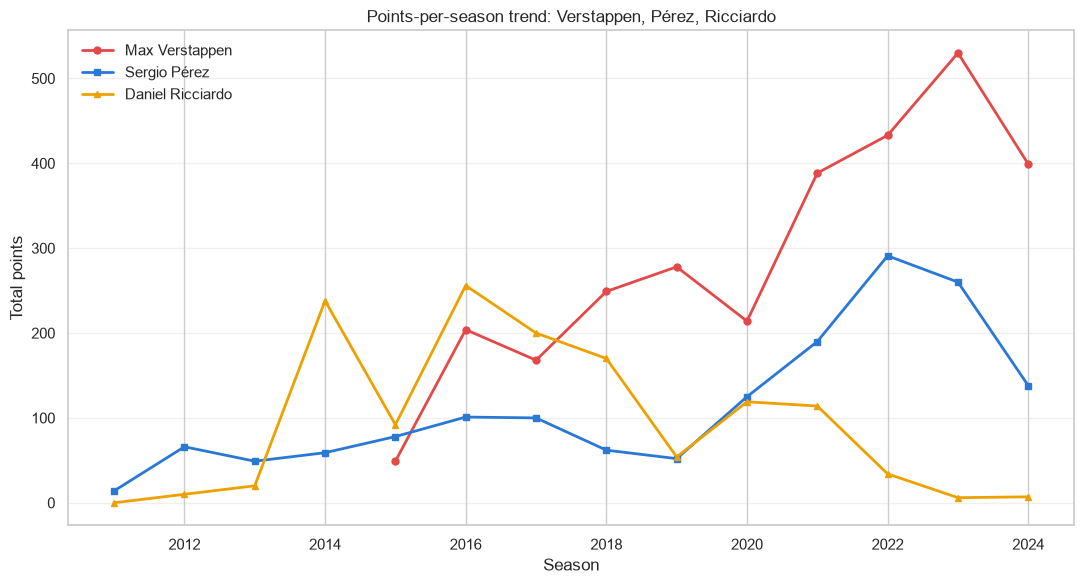

In [649]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv('data/results.csv')
races = pd.read_csv('data/races.csv')
drivers = pd.read_csv('data/drivers.csv')

results = results.merge(races[['raceId', 'year']], on='raceId', how='left')
drivers['driver_name'] = drivers['forename'] + ' ' + drivers['surname']
results = results.merge(drivers[['driverId', 'driver_name']], on='driverId', how='left')

# Verstappen(10seasons)
# Pérez(14seasons)
# Ricciardo(14seasons)

chosen = ['Max Verstappen', 'Sergio Pérez', 'Daniel Ricciardo']

# sum of the points per season for each driver
season_points = (
    results[results['driver_name'].isin(chosen)]
    .groupby(['driver_name', 'year'])['points']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))
colors = {'Max Verstappen': '#e34948', 'Sergio Pérez': '#2a78d6', 'Daniel Ricciardo': '#eda100'}
markers = {'Max Verstappen': 'o', 'Sergio Pérez': 's', 'Daniel Ricciardo': '^'}

for driver in chosen:
    d = season_points[season_points['driver_name'] == driver].sort_values('year')
    ax.plot(d['year'], d['points'], marker=markers[driver], label=driver,
            color=colors[driver], linewidth=2, markersize=5)

ax.set_xlabel('Season')
ax.set_ylabel('Total points')
ax.set_title('Points-per-season trend: Verstappen, Pérez, Ricciardo')
ax.legend(loc='upper left', frameon=False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('jaeeun/output/chart4_driver_trends.png', dpi=150)
plt.show()

Verstappen shows the clearest sustained rise: steady growth from his 2015 debut, a competitive plateau in 2018-2020, then an explosive climb from 2021 onward, peaking at 530 points in 2023. Pérez follows a flatter, more volatile path oscillating in the 50-125 range for a decade before a late-career surge in 2021-2023 as Red Bull's second driver, then a sharp 2024 decline. Ricciardo's arc is the most dramatic rise-and-fall: a strong peak in 2014 and 2016 (256 points) as a genuine title contender at Red Bull, followed by a long, steady decline through McLaren and a struggling Red Bull return, bottoming out at single-digit points by 2023-2024.

## Normalization : theoritical max points

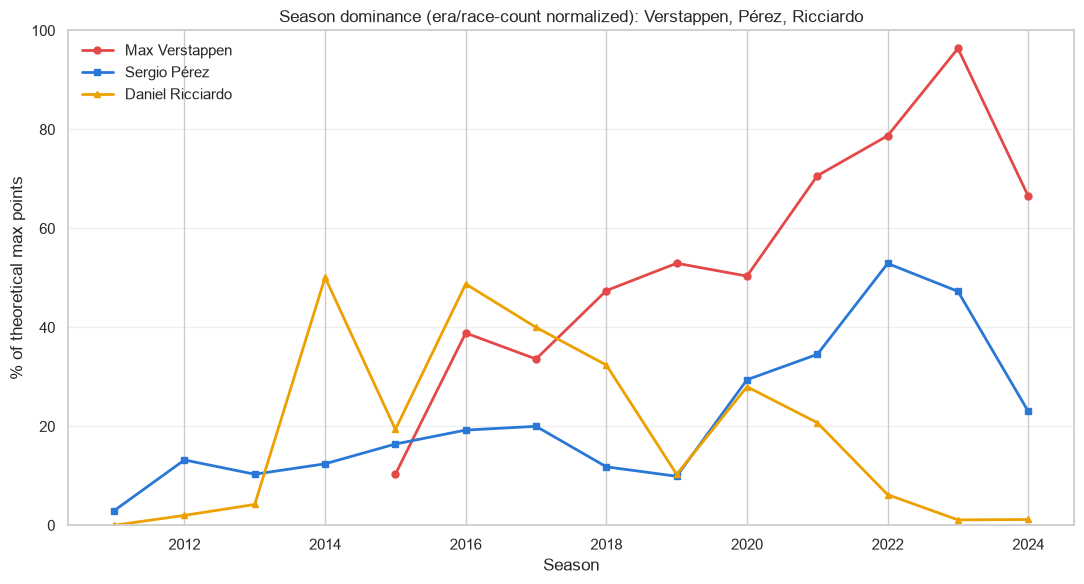

In [650]:
results = pd.read_csv('data/results.csv')
races = pd.read_csv('data/races.csv')
drivers = pd.read_csv('data/drivers.csv')

results = results.merge(races[['raceId', 'year']], on='raceId', how='left')
drivers['driver_name'] = drivers['forename'] + ' ' + drivers['surname']
results = results.merge(drivers[['driverId', 'driver_name']], on='driverId', how='left')

chosen = ['Max Verstappen', 'Sergio Pérez', 'Daniel Ricciardo']

season_points = (
    results[results['driver_name'].isin(chosen)]
    .groupby(['driver_name', 'year'])['points']
    .sum()
    .reset_index()
)

races_per_season = races.groupby('year')['round'].max()
season_points['races_in_season'] = season_points['year'].map(races_per_season)

def max_possible_points(n_races, points_per_win=25):
    return n_races * points_per_win

season_points['pct_of_max'] = season_points['points'] / season_points['races_in_season'].apply(max_possible_points) * 100

fig, ax = plt.subplots(figsize=(11, 6))
colors = {'Max Verstappen': '#e34948', 'Sergio Pérez': '#2a78d6', 'Daniel Ricciardo': '#eda100'}
markers = {'Max Verstappen': 'o', 'Sergio Pérez': 's', 'Daniel Ricciardo': '^'}

for driver in chosen:
    d = season_points[season_points['driver_name'] == driver].sort_values('year')
    ax.plot(d['year'], d['pct_of_max'], marker=markers[driver], label=driver,
            color=colors[driver], linewidth=2, markersize=5)

ax.set_xlabel('Season')
ax.set_ylabel('% of theoretical max points')
ax.set_title('Season dominance (era/race-count normalized): Verstappen, Pérez, Ricciardo')
ax.set_ylim(0, 100)
ax.legend(loc='upper left', frameon=False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('jaeeun/output/chart5_pct_of_max.png', dpi=150)
plt.show()

## Cross-era normalization: Verstappen vs. Schumacher vs. Alonso

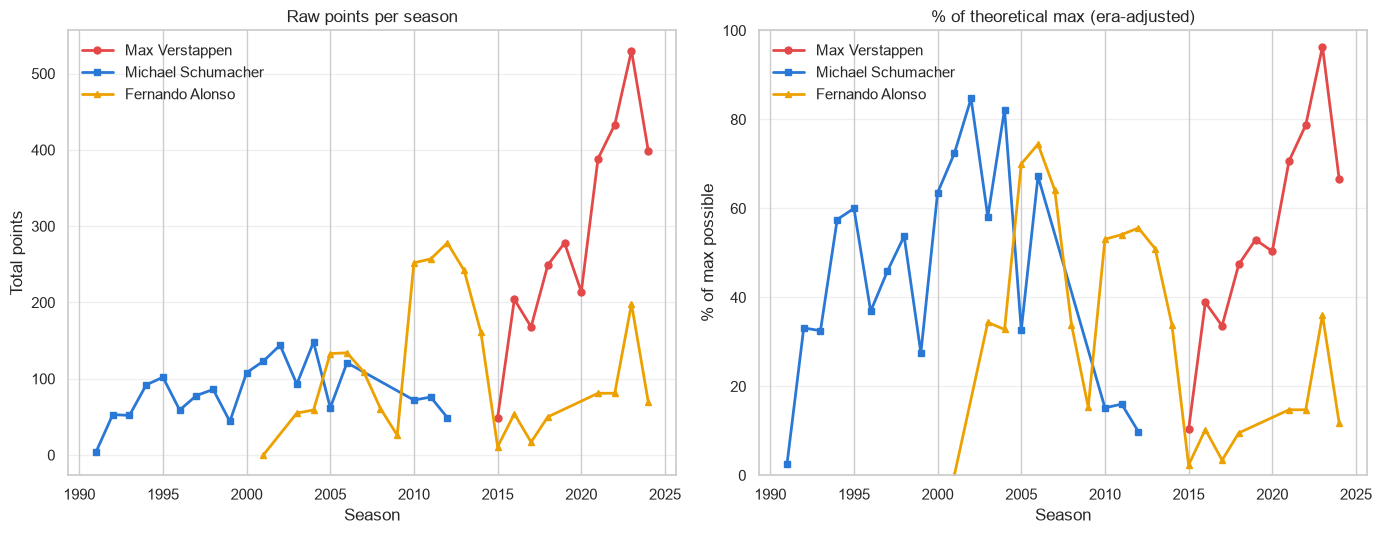

In [651]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv('data/results.csv')
races = pd.read_csv('data/races.csv')
drivers = pd.read_csv('data/drivers.csv')

results = results.merge(races[['raceId', 'year']], on='raceId', how='left')
drivers['driver_name'] = drivers['forename'] + ' ' + drivers['surname']
results = results.merge(drivers[['driverId', 'driver_name']], on='driverId', how='left')

chosen = ['Max Verstappen', 'Michael Schumacher', 'Fernando Alonso']

season_points = (
    results[results['driver_name'].isin(chosen)]
    .groupby(['driver_name', 'year'])['points']
    .sum()
    .reset_index()
)

races_per_season = races.groupby('year')['round'].max()
season_points['races_in_season'] = season_points['year'].map(races_per_season)

def points_per_win(year):
    if year < 1991:
        return 9
    elif year < 2010:
        return 10
    else:
        return 25

season_points['win_points'] = season_points['year'].apply(points_per_win)
season_points['max_possible'] = season_points['races_in_season'] * season_points['win_points']
season_points['pct_of_max'] = season_points['points'] / season_points['max_possible'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = {'Max Verstappen': '#e34948', 'Michael Schumacher': '#2a78d6', 'Fernando Alonso': '#eda100'}
markers = {'Max Verstappen': 'o', 'Michael Schumacher': 's', 'Fernando Alonso': '^'}

for driver in chosen:
    d = season_points[season_points['driver_name'] == driver].sort_values('year')
    axes[0].plot(d['year'], d['points'], marker=markers[driver], label=driver, color=colors[driver], linewidth=2, markersize=5)
    axes[1].plot(d['year'], d['pct_of_max'], marker=markers[driver], label=driver, color=colors[driver], linewidth=2, markersize=5)

axes[0].set_title('Raw points per season')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Total points')
axes[0].legend(loc='upper left', frameon=False); axes[0].grid(axis='y', alpha=0.3)

axes[1].set_title('% of theoretical max (era-adjusted)')
axes[1].set_xlabel('Season'); axes[1].set_ylabel('% of max possible')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left', frameon=False); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('jaeeun/output/chart6_2000s_comparison.png', dpi=150)
plt.show()

Since normalizing by race count alone produced results nearly identical to the raw points comparison for drivers active within the same era, the same logic was applied to drivers active in markedly different eras — Schumacher and Alonso — to see whether normalization would reveal something the raw points couldn't. The results showed a clear difference between the two graphs. Because F1's points-per-win value has increased over time (from 9, to 10, to the current 25), Schumacher's and Alonso's raw point totals look modest next to Verstappen's. But once each season is expressed as a percentage of that season's theoretical maximum, both drivers turn out to have been performing at a genuinely elite level — Schumacher's 2002 reaches 84.7% and Alonso's 2006 reaches 74.4%, far closer to modern standards than their raw totals suggested.

At the same time, the normalized comparison confirms that Verstappen still earned the highest percentage of the three, with 2023 reaching 96.4% — the most dominant single season even after adjusting for era. These results reinforce the value of era-adjustment: Verstappen's 2023 remains the standout season in this comparison, but Schumacher's 2002 sits much closer to it than raw points suggest, and the "shape" of Alonso's career peak shifts once the scoring-system change is accounted for.

# Task15 - Predictive Mini-Model

### Approach 1 - Logistic Regression

Feature Set
| Category | Features |
|---|---|
| Static | grid, constructorId, circuitId |
| Qualifying detail | qualifying gap to pole, Q1/Q2/Q3 progression |
| Form | prior-round driver/constructor standings, rolling 5-race average finish |
| Reliability | historical DNF rate |
| Circuit fit | driver's historical Top-10 rate at that circuit |

In [652]:
import pandas as pd
import numpy as np

results = pd.read_csv('data/results.csv')
races = pd.read_csv('data/races.csv')
qualifying = pd.read_csv('data/qualifying.csv')
driver_standings = pd.read_csv('data/driver_standings.csv')
constructor_standings = pd.read_csv('data/constructor_standings.csv')

df = results.merge(races[['raceId', 'year', 'round', 'circuitId', 'date']], on='raceId')

# add top10 column to results
df['top10'] = (df['positionOrder'] <= 10).astype(int)

# sort by year and round for proper chronological order
df = df.sort_values(['year', 'round']).reset_index(drop=True)

In [653]:
# add prior round standings to avoid data leakage
def add_prior_round(standings_df, cols_to_use, prefix):
    s = standings_df.merge(races[['raceId', 'year', 'round']], on='raceId')
    s['round_next'] = s['round'] + 1
    s = s.rename(columns={c: f'{prefix}_{c}' for c in cols_to_use})
    return s[['driverId' if 'driver' in prefix else 'constructorId', 'year', 'round_next'] +
              [f'{prefix}_{c}' for c in cols_to_use]]

driver_std_prior = add_prior_round(driver_standings, ['points', 'position'], 'driver_std')
constructor_std_prior = add_prior_round(constructor_standings, ['points', 'position'], 'constructor_std')

df = df.merge(driver_std_prior, left_on=['driverId', 'year', 'round'],
              right_on=['driverId', 'year', 'round_next'], how='left')
df = df.merge(constructor_std_prior, left_on=['constructorId', 'year', 'round'],
              right_on=['constructorId', 'year', 'round_next'], how='left')

# first race in a season -> fill points with 0 and position with 21
for col in ['driver_std_points', 'driver_std_position', 'constructor_std_points', 'constructor_std_position']:
    df[col] = df[col].fillna(0 if 'points' in col else 21)  

In [654]:
q = qualifying[['raceId', 'driverId', 'q1', 'q2', 'q3', 'position']].rename(
    columns={'position': 'quali_position'})

def to_seconds(t):
    if pd.isna(t) or t == '\\N':
        return np.nan
    m, s = t.split(':')
    return int(m) * 60 + float(s) 

for col in ['q1', 'q2', 'q3']:
    q[col] = q[col].apply(to_seconds)

q['best_quali_time'] = q[['q1', 'q2', 'q3']].min(axis=1)
q['pole_time'] = q.groupby('raceId')['best_quali_time'].transform('min')
q['quali_gap_to_pole'] = q['best_quali_time'] - q['pole_time']

df = df.merge(q[['raceId', 'driverId', 'quali_position', 'quali_gap_to_pole']],
              on=['raceId', 'driverId'], how='left')
df['quali_gap_to_pole'] = df['quali_gap_to_pole'].fillna(df['quali_gap_to_pole'].median())

In [655]:
df = df.sort_values(['driverId', 'year', 'round'])

# average finish position in the last 5 races
df['driver_form_last5'] = df.groupby('driverId')['positionOrder'] \
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())

# past top10 rate in a certain circuit 
df['circuit_top10_rate'] = df.groupby(['driverId', 'circuitId'])['top10'] \
    .transform(lambda x: x.shift(1).expanding().mean())

# past DNF rate
status = pd.read_csv('data/status.csv')
finished_ids = status[status['status'].str.contains('Finished|Lap', case=False, na=False)]['statusId']
df['finished'] = df['statusId'].isin(finished_ids).astype(int)
df['driver_dnf_rate'] = df.groupby('driverId')['finished'] \
    .transform(lambda x: 1 - x.shift(1).expanding().mean())

# NaN cases
for col in ['driver_form_last5', 'circuit_top10_rate', 'driver_dnf_rate']:
    df[col] = df[col].fillna(df[col].median())

df = df.sort_values(['year', 'round']).reset_index(drop=True)

In [656]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

numeric_features = [
    'grid', 'driver_std_points', 'driver_std_position',
    'constructor_std_points', 'constructor_std_position',
    'quali_position', 'quali_gap_to_pole',
    'driver_form_last5', 'circuit_top10_rate', 'driver_dnf_rate'
]


categorical_features = ['constructorId', 'circuitId']

for col in numeric_features:
    if df[col].isna().sum() > 0:
        median_val = df.loc[df['year'] <= 2022, col].median()
        df[col] = df[col].fillna(median_val)

assert df[numeric_features].isna().sum().sum() == 0, "df에 여전히 NaN 있음"
X = pd.get_dummies(df[numeric_features + categorical_features],
                    columns=categorical_features, drop_first=True)
y = df['top10']


train_mask = df['year'] <= 2022
test_mask = df['year'] > 2022

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("X_train NaN:", X_train.isna().sum().sum())
print("X_test NaN :", X_test.isna().sum().sum())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_test_scaled = scaler.transform(X_test[numeric_features])

# merging scaled numeric + one-hot categorical
import scipy.sparse as sp
X_train_final = np.hstack([X_train_scaled, X_train.drop(columns=numeric_features).values])
X_test_final = np.hstack([X_test_scaled, X_test.drop(columns=numeric_features).values])

X_train NaN: 0
X_test NaN : 0


### Logistic Regression Results

In [657]:
# baseline model: grid <= 10 → top10
baseline_pred = (df.loc[test_mask, 'grid'] <= 10).astype(int)
baseline_acc = accuracy_score(y_test, baseline_pred)


# logistic regression model
model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train_final, y_train)
y_pred = model.predict(X_test_final)

print(f"Baseline Accuracy      : {baseline_acc:.3f}")
print(f"Logistic Reg Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
print("\n[Classification Report]")
print(classification_report(y_test, y_pred))
print("[Confusion Matrix]")
print(confusion_matrix(y_test, y_pred))


# Feature Importance 
feature_names = numeric_features + list(X_train.drop(columns=numeric_features).columns)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_[0]
})
importance_df['abs_coefficient'] = importance_df['coefficient'].abs()
importance_df = importance_df.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)


Baseline Accuracy      : 0.767
Logistic Reg Accuracy  : 0.811

[Classification Report]
              precision    recall  f1-score   support

           0       0.86      0.75      0.80       459
           1       0.78      0.87      0.82       460

    accuracy                           0.81       919
   macro avg       0.82      0.81      0.81       919
weighted avg       0.82      0.81      0.81       919

[Confusion Matrix]
[[343 116]
 [ 58 402]]


### Results Analysis

**1. Marginal Improvement Over Baseline**
- Logistic regression (0.811) only outperforms the baseline (0.767) by 1.2 points. 
- This suggests **that grid alone already captures most of the predictive signal for Top-10 finishes.** The additional features (qualifying gap, standings, rolling form) overlap heavily with information grid already encodes.

**2. Asymmetric Performance Across Classes**
- **Class 1 (Top10 finish)**: recall 0.87 → model reliably identifies drivers who finish Top10
- **Class 0 (non-Top10 finish)**: recall 0.68 → model misses 32% of drivers who actually finish outside Top10 (145 false positives)

### Limitations of Current Approach

**Limitation 1: No Features Capture Stochastic Events (DNFs/Crashes)**

**Limitation 2: Multicollinearity Among Qualifying-Related Features**

## Feature importance

In [658]:
# constructor 관련 계수들의 절댓값 합 vs 다른 feature들 비교
constructor_cols = [c for c in feature_names if c.startswith('constructorId_')]
circuit_cols = [c for c in feature_names if c.startswith('circuitId_')]
numeric_cols = [c for c in feature_names if c in numeric_features]

group_importance = {
    'constructor (sum)': importance_df[importance_df['feature'].isin(constructor_cols)]['abs_coefficient'].sum(),
    'circuit (sum)': importance_df[importance_df['feature'].isin(circuit_cols)]['abs_coefficient'].sum(),
}
for f in numeric_cols:
    group_importance[f] = importance_df[importance_df['feature'] == f]['abs_coefficient'].values[0]

group_df = pd.DataFrame(list(group_importance.items()), columns=['feature_group', 'total_importance'])
group_df = group_df.sort_values('total_importance', ascending=False)
print(group_df)

               feature_group  total_importance
0          constructor (sum)         98.900365
1              circuit (sum)         18.455357
7             quali_position          0.435453
9          driver_form_last5          0.387161
4        driver_std_position          0.179644
11           driver_dnf_rate          0.085203
5     constructor_std_points          0.083657
6   constructor_std_position          0.078697
2                       grid          0.071166
3          driver_std_points          0.045806
10        circuit_top10_rate          0.045730
8          quali_gap_to_pole          0.026106


## Removing Constructor ID

Initial feature importance analysis (based on logistic regression coefficients) showed that `constructorId`, when one-hot encoded, dominated the model's decision-making almost entirely. This indicated that the model was, in practice, relying almost exclusively on team identity to predict Top-10 finishes, while carefully engineered features such as qualifying gap, recent form, and driver standings contributed almost nothing to the decision.

To test this hypothesis, `constructorId` was removed from the feature set and the model was retrained using only the remaining features. This allowed the true contribution of each remaining feature to be re-evaluated without being masked by the disproportionately large constructor effect.

In [659]:
# Training without constructorId


# circuitId one-hot encoding
X_no_constructor = pd.get_dummies(df[numeric_features + ['circuitId']],
                                    columns=['circuitId'], drop_first=True)
y_no_constructor = df['top10']

X_train_nc, X_test_nc = X_no_constructor[train_mask], X_no_constructor[test_mask]
y_train_nc, y_test_nc = y_no_constructor[train_mask], y_no_constructor[test_mask]

# scaling
scaler_nc = StandardScaler()
X_train_nc_scaled = scaler_nc.fit_transform(X_train_nc[numeric_features])
X_test_nc_scaled = scaler_nc.transform(X_test_nc[numeric_features])

X_train_nc_final = np.hstack([X_train_nc_scaled, X_train_nc.drop(columns=numeric_features).values])
X_test_nc_final = np.hstack([X_test_nc_scaled, X_test_nc.drop(columns=numeric_features).values])

# training
model_nc = LogisticRegression(max_iter=2000, class_weight='balanced')
model_nc.fit(X_train_nc_final, y_train_nc)
y_pred_nc = model_nc.predict(X_test_nc_final)

acc_nc = accuracy_score(y_test_nc, y_pred_nc)

print(f"Accuracy including Constructor   : {acc:.3f}")
print(f"Accuracy excluding Constructor   : {acc_nc:.3f}")
print("\n[Classification Report - Constructor 제외]")
print(classification_report(y_test_nc, y_pred_nc))
print("[Confusion Matrix]")
print(confusion_matrix(y_test_nc, y_pred_nc))

Accuracy including Constructor   : 0.811
Accuracy excluding Constructor   : 0.816

[Classification Report - Constructor 제외]
              precision    recall  f1-score   support

           0       0.85      0.77      0.81       459
           1       0.79      0.86      0.82       460

    accuracy                           0.82       919
   macro avg       0.82      0.82      0.82       919
weighted avg       0.82      0.82      0.82       919

[Confusion Matrix]
[[353 106]
 [ 63 397]]


In [660]:
feature_names_nc = numeric_features + list(X_train_nc.drop(columns=numeric_features).columns)

importance_nc = pd.DataFrame({
    'feature': feature_names_nc,
    'coefficient': model_nc.coef_[0]
})
importance_nc['abs_coefficient'] = importance_nc['coefficient'].abs()
importance_nc = importance_nc.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

# numeric feature들만 따로 확인 (circuit 그룹과 분리)
numeric_importance_nc = importance_nc[importance_nc['feature'].isin(numeric_features)]
print("\n[Constructor 제외 시 - Numeric Feature Importance]")
print(numeric_importance_nc.to_string(index=False))


[Constructor 제외 시 - Numeric Feature Importance]
                 feature  coefficient  abs_coefficient
       driver_form_last5    -0.518362         0.518362
          quali_position    -0.475073         0.475073
  constructor_std_points     0.235121         0.235121
     driver_std_position    -0.202558         0.202558
                    grid    -0.093323         0.093323
constructor_std_position    -0.084209         0.084209
       driver_std_points    -0.079567         0.079567
         driver_dnf_rate     0.060374         0.060374
      circuit_top10_rate     0.052519         0.052519
       quali_gap_to_pole     0.020150         0.020150


In [661]:
df = df.sort_values(['driverId', 'year', 'round'])

df['driver_form_last3'] = df.groupby('driverId')['positionOrder'] \
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())

df['driver_form_trend'] = df['driver_form_last3'] - df['driver_form_last5']

df = df.sort_values(['year', 'round']).reset_index(drop=True)

for col in ['driver_form_last3', 'driver_form_trend']:
    df[col] = df[col].fillna(df.loc[df['year'] <= 2022, col].median())

## Result Analysis : Removing Constructor ID Improved Accuracy

Contrary to the expectation that removing a feature would reduce predictive power, excluding `constructorId` from the model **increased** test accuracy from 0.811 to **0.816**, the highest accuracy achieved across all model iterations in this project.

 With `constructorId` removed, feature importance became more evenly and meaningfully distributed across qualifying position, recent driver form, and team standings. It indicates that these features, previously overshadowed by team identity, do carry real predictive value on their own.

## Refining time-series features
- EWM-based form
- constructor tenure

In [662]:
numeric_features_v5 = numeric_features + \
                       ['driver_form_last3', 'driver_form_trend']

X_v5 = pd.get_dummies(df[numeric_features_v5 + ['circuitId']],
                       columns=['circuitId'], drop_first=True)
X_train_v5, X_test_v5 = X_v5[train_mask], X_v5[test_mask]

scaler_v5 = StandardScaler()
X_train_v5_scaled = scaler_v5.fit_transform(X_train_v5[numeric_features_v5])
X_test_v5_scaled = scaler_v5.transform(X_test_v5[numeric_features_v5])
X_train_v5_final = np.hstack([X_train_v5_scaled, X_train_v5.drop(columns=numeric_features_v5).values])
X_test_v5_final = np.hstack([X_test_v5_scaled, X_test_v5.drop(columns=numeric_features_v5).values])

model_v5 = LogisticRegression(max_iter=2000, class_weight='balanced')
model_v5.fit(X_train_v5_final, y_train)
y_pred_v5 = model_v5.predict(X_test_v5_final)
acc_v5 = accuracy_score(y_test, y_pred_v5)

print(f"strengthening recent form  : {acc_v5:.3f}")
print(classification_report(y_test, y_pred_v5))

strengthening recent form  : 0.813
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       459
           1       0.79      0.85      0.82       460

    accuracy                           0.81       919
   macro avg       0.82      0.81      0.81       919
weighted avg       0.81      0.81      0.81       919



### 

In [663]:
# 1) ewm recent form 
df = df.sort_values(['driverId', 'year', 'round'])
df['driver_form_ewm'] = df.groupby('driverId')['positionOrder'] \
    .transform(lambda x: x.shift(1).ewm(span=5, min_periods=1).mean())
df = df.sort_values(['year', 'round']).reset_index(drop=True)

# 2) the number of races with the same constructor
df = df.sort_values(['driverId', 'constructorId', 'year', 'round'])
df['races_with_constructor'] = df.groupby(['driverId', 'constructorId']).cumcount()
df = df.sort_values(['year', 'round']).reset_index(drop=True)

new_ts_features = ['driver_form_ewm', 'races_with_constructor']
for col in new_ts_features:
    df[col] = df[col].fillna(df.loc[df['year'] <= 2022, col].median())

print(df[new_ts_features].isna().sum())

driver_form_ewm           0
races_with_constructor    0
dtype: int64


In [664]:
numeric_features_v6 = numeric_features +\
                       ['driver_form_last3', 'driver_form_trend'] + \
                       new_ts_features

X_v6 = pd.get_dummies(df[numeric_features_v6 + ['circuitId']],
                       columns=['circuitId'], drop_first=True)
y_v6 = df['top10']

X_train_v6, X_test_v6 = X_v6[train_mask], X_v6[test_mask]
y_train_v6, y_test_v6 = y_v6[train_mask], y_v6[test_mask]

In [665]:
scaler_v6 = StandardScaler()
X_train_v6_scaled = scaler_v6.fit_transform(X_train_v6[numeric_features_v6])
X_test_v6_scaled = scaler_v6.transform(X_test_v6[numeric_features_v6])

X_train_v6_final = np.hstack([X_train_v6_scaled, X_train_v6.drop(columns=numeric_features_v6).values])
X_test_v6_final = np.hstack([X_test_v6_scaled, X_test_v6.drop(columns=numeric_features_v6).values])

model_v6 = LogisticRegression(max_iter=2000, class_weight='balanced')
model_v6.fit(X_train_v6_final, y_train_v6)
y_pred_v6 = model_v6.predict(X_test_v6_final)

acc_v6 = accuracy_score(y_test_v6, y_pred_v6)

print(f"Logistic Regression without using ConstructorId     : {acc_nc:.3f}")
print(f"considering EWM form andthe number of races with the same constructor      : {acc_v6:.3f}")
print("\n[Classification Report]")
print(classification_report(y_test_v6, y_pred_v6))
print("[Confusion Matrix]")
print(confusion_matrix(y_test_v6, y_pred_v6))

Logistic Regression without using ConstructorId     : 0.816
considering EWM form andthe number of races with the same constructor      : 0.813

[Classification Report]
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       459
           1       0.78      0.87      0.82       460

    accuracy                           0.81       919
   macro avg       0.82      0.81      0.81       919
weighted avg       0.82      0.81      0.81       919

[Confusion Matrix]
[[349 110]
 [ 62 398]]


In [666]:
feature_names_v6 = numeric_features_v6 + list(X_train_v6.drop(columns=numeric_features_v6).columns)

importance_v6 = pd.DataFrame({
    'feature': feature_names_v6,
    'coefficient': model_v6.coef_[0]
})
importance_v6['abs_coefficient'] = importance_v6['coefficient'].abs()
importance_v6 = importance_v6.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

numeric_importance_v6 = importance_v6[importance_v6['feature'].isin(numeric_features_v6)]
print(numeric_importance_v6.to_string(index=False))

                 feature  coefficient  abs_coefficient
       driver_form_last5     0.764277         0.764277
       driver_form_last3    -0.761624         0.761624
         driver_form_ewm    -0.634868         0.634868
          quali_position    -0.466015         0.466015
       driver_form_trend     0.361352         0.361352
  constructor_std_points     0.236803         0.236803
     driver_std_position    -0.167580         0.167580
       driver_std_points    -0.108182         0.108182
         driver_dnf_rate     0.087055         0.087055
                    grid    -0.086879         0.086879
constructor_std_position    -0.079033         0.079033
  races_with_constructor     0.075767         0.075767
      circuit_top10_rate     0.044364         0.044364
       quali_gap_to_pole     0.020493         0.020493


## Approach 2 - HistGradientBoosting Acc
removed
- quali position
- grid

added
- constructor & circuit top10 rate
- grid_pct instead of grid
- teammate qualifying gap

In [667]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

results = pd.read_csv('data/results.csv')
races = pd.read_csv('data/races.csv')
qualifying = pd.read_csv('data/qualifying.csv')
driver_standings = pd.read_csv('data/driver_standings.csv')
constructor_standings = pd.read_csv('data/constructor_standings.csv')
status = pd.read_csv('data/status.csv')

df = results.merge(races[['raceId', 'year', 'round', 'circuitId']], on='raceId')
df['top10'] = (df['positionOrder'] <= 10).astype(int)
df = df.sort_values(['year', 'round']).reset_index(drop=True)

In [668]:
#prior round standings to avoid data leakage
def add_prior_round(standings_df, cols_to_use, prefix, id_col):
    s = standings_df.merge(races[['raceId', 'year', 'round']], on='raceId')
    s['round_next'] = s['round'] + 1
    s = s.rename(columns={c: f'{prefix}_{c}' for c in cols_to_use})
    return s[[id_col, 'year', 'round_next'] + [f'{prefix}_{c}' for c in cols_to_use]]

driver_std_prior = add_prior_round(driver_standings, ['points', 'position'], 'driver_std', 'driverId')
constructor_std_prior = add_prior_round(constructor_standings, ['points', 'position'], 'constructor_std', 'constructorId')

df = df.merge(driver_std_prior, left_on=['driverId', 'year', 'round'],
              right_on=['driverId', 'year', 'round_next'], how='left')
df = df.merge(constructor_std_prior, left_on=['constructorId', 'year', 'round'],
              right_on=['constructorId', 'year', 'round_next'], how='left')

for col in ['driver_std_points', 'driver_std_position', 'constructor_std_points', 'constructor_std_position']:
    df[col] = df[col].fillna(0 if 'points' in col else 21)

In [669]:
# Add qualifying gap to pole position
q = qualifying[['raceId', 'driverId', 'q1', 'q2', 'q3']].copy()

def to_seconds(t):
    if pd.isna(t) or t == '\\N':
        return np.nan
    m, s = t.split(':')
    return int(m) * 60 + float(s)

for col in ['q1', 'q2', 'q3']:
    q[col] = q[col].apply(to_seconds)

q['best_quali_time'] = q[['q1', 'q2', 'q3']].min(axis=1)
q['pole_time'] = q.groupby('raceId')['best_quali_time'].transform('min')
q['quali_gap_to_pole'] = q['best_quali_time'] - q['pole_time']

df = df.merge(q[['raceId', 'driverId', 'quali_gap_to_pole']], on=['raceId', 'driverId'], how='left')

# qualifying failure/missing cases: fill with 1.5x max gap
max_gap = df.groupby('raceId')['quali_gap_to_pole'].transform('max')
df['quali_gap_to_pole'] = df['quali_gap_to_pole'].fillna(max_gap * 1.5)
df['quali_gap_to_pole'] = df['quali_gap_to_pole'].fillna(
    df.loc[df['year'] <= 2022, 'quali_gap_to_pole'].median()
)

In [670]:
df = df.sort_values(['driverId', 'year', 'round'])

# recent form : average finish position in the last
df['driver_form_last5'] = df.groupby('driverId')['positionOrder'] \
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())


# past top10 rate in a certain circuit
df['circuit_top10_rate'] = df.groupby(['driverId', 'circuitId'])['top10'] \
    .transform(lambda x: x.shift(1).expanding().mean())

# DNF rate
finished_ids = status[status['status'].str.contains('Finished|Lap', case=False, na=False)]['statusId']
df['finished'] = df['statusId'].isin(finished_ids).astype(int)
df['driver_dnf_rate'] = df.groupby('driverId')['finished'] \
    .transform(lambda x: 1 - x.shift(1).expanding().mean())

df = df.sort_values(['year', 'round']).reset_index(drop=True)

for col in ['driver_form_last5', 'circuit_top10_rate', 'driver_dnf_rate']:
    df[col] = df[col].fillna(df.loc[df['year'] <= 2022, col].median())

In [671]:
# constructor-circuit top10 rate
df = df.sort_values(['constructorId', 'circuitId', 'year', 'round'])
df['constructor_circuit_top10_rate'] = df.groupby(['constructorId', 'circuitId'])['top10'] \
    .transform(lambda x: x.shift(1).expanding().mean())
df = df.sort_values(['year', 'round']).reset_index(drop=True)

# grid position percentage 
df['grid_size'] = df.groupby('raceId')['grid'].transform('count')
df['grid_pct'] = df['grid'] / df['grid_size']

# teammate gap
df['teammate_quali_gap'] = df.groupby(['raceId', 'constructorId'])['quali_gap_to_pole'] \
    .transform(lambda x: x - x.mean())

for col in ['constructor_circuit_top10_rate', 'grid_pct', 'teammate_quali_gap']:
    df[col] = df[col].fillna(df.loc[df['year'] <= 2022, col].median())

In [672]:
# grid, quali_position 제거 → grid_pct, quali_gap_to_pole로 대체 (중복 정보 정리)
numeric_features = [
    'grid_pct',
    'driver_std_points', 'driver_std_position',
    'constructor_std_points', 'constructor_std_position',
    'quali_gap_to_pole', 'teammate_quali_gap',
    'driver_form_last5', 'circuit_top10_rate', 'constructor_circuit_top10_rate',
    'driver_dnf_rate'
]

categorical_features = ['constructorId', 'circuitId']

X = pd.get_dummies(df[numeric_features + categorical_features],
                    columns=categorical_features, drop_first=True)
y = df['top10']

train_mask = df['year'] <= 2022
test_mask = df['year'] > 2022

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("X_train NaN:", X_train.isna().sum().sum())
print("X_test NaN :", X_test.isna().sum().sum())

X_train NaN: 0
X_test NaN : 0


In [673]:
# baseline
baseline_pred = (df.loc[test_mask, 'grid'] <= 10).astype(int)
baseline_acc = accuracy_score(y_test, baseline_pred)

sample_weight = np.where(y_train == 1, 1.0, (y_train == 1).sum() / (y_train == 0).sum())

hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(X_train, y_train, sample_weight=sample_weight)
y_pred = hgb.predict(X_test)

print(f"Baseline Accuracy         : {baseline_acc:.3f}")
print(f"HistGradientBoosting Acc  : {accuracy_score(y_test, y_pred):.3f}")
print("\n[Classification Report]")
print(classification_report(y_test, y_pred))
print("[Confusion Matrix]")
print(confusion_matrix(y_test, y_pred))

Baseline Accuracy         : 0.767
HistGradientBoosting Acc  : 0.811

[Classification Report]
              precision    recall  f1-score   support

           0       0.86      0.74      0.80       459
           1       0.77      0.88      0.82       460

    accuracy                           0.81       919
   macro avg       0.82      0.81      0.81       919
weighted avg       0.82      0.81      0.81       919

[Confusion Matrix]
[[339 120]
 [ 54 406]]


### Hyperparameter tuning on HistGradientBoostingClassifier

In [674]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'max_depth': [3, 5, 7, None],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_iter': [100, 200],
    'l2_regularization': [0.0, 1.0]
}

hgb_base = HistGradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=hgb_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train, sample_weight=sample_weight)

print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'max_iter': 100}
Best CV accuracy: 0.706661240021485


In [675]:
best_hgb = grid_search.best_estimator_
y_pred_best = best_hgb.predict(X_test)

print(f"Baseline Accuracy              : {baseline_acc:.3f}")
print(f"Tuned HistGradientBoosting Acc : {accuracy_score(y_test, y_pred_best):.3f}")
print("\n[Classification Report]")
print(classification_report(y_test, y_pred_best))
print("[Confusion Matrix]")
print(confusion_matrix(y_test, y_pred_best))

Baseline Accuracy              : 0.767
Tuned HistGradientBoosting Acc : 0.805

[Classification Report]
              precision    recall  f1-score   support

           0       0.85      0.75      0.79       459
           1       0.77      0.87      0.82       460

    accuracy                           0.81       919
   macro avg       0.81      0.81      0.80       919
weighted avg       0.81      0.81      0.80       919

[Confusion Matrix]
[[342 117]
 [ 62 398]]


In [676]:
# setting dataset only after 1994
train_mask_1994 = (df['year'] >= 1994) & (df['year'] <= 2022)
test_mask = df['year'] > 2022  # test는 그대로 2023년 이후 유지

print(f"the number of samples after 1994: {train_mask_1994.sum()}")
print(f"the number of samples in total: {train_mask.sum()}")

the number of samples after 1994: 11439
the number of samples in total: 25840


In [677]:
X_train_v3, X_test_v3 = X[train_mask_1994], X[test_mask]
y_train_v3, y_test_v3 = y[train_mask_1994], y[test_mask]

scaler_v3 = StandardScaler()
X_train_v3_scaled = scaler_v3.fit_transform(X_train_v3[numeric_features])
X_test_v3_scaled = scaler_v3.transform(X_test_v3[numeric_features])

X_train_v3_final = np.hstack([X_train_v3_scaled, X_train_v3.drop(columns=numeric_features).values])
X_test_v3_final = np.hstack([X_test_v3_scaled, X_test_v3.drop(columns=numeric_features).values])

model_v3 = LogisticRegression(max_iter=2000, class_weight='balanced')
model_v3.fit(X_train_v3_final, y_train_v3)
y_pred_v3 = model_v3.predict(X_test_v3_final)

acc_v3 = accuracy_score(y_test_v3, y_pred_v3)
print(f"[v3] Logistic Regression (trained after 1994) Accuracy: {acc_v3:.3f}")
print(classification_report(y_test_v3, y_pred_v3))
print(confusion_matrix(y_test_v3, y_pred_v3))

[v3] Logistic Regression (trained after 1994) Accuracy: 0.801
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       459
           1       0.78      0.84      0.81       460

    accuracy                           0.80       919
   macro avg       0.80      0.80      0.80       919
weighted avg       0.80      0.80      0.80       919

[[349 110]
 [ 73 387]]


In [678]:
# setting train_mask to only include data after 2000
train_mask_2000 = (df['year'] >= 2000) & (df['year'] <= 2022)
test_mask = df['year'] > 2022  # test는 그대로 2023년 이후 유지

print(f"the number of samples after 2000: {train_mask_2000.sum()}")
print(f"the number of samples in total: {train_mask.sum()}")

X_train_v3, X_test_v3 = X[train_mask_2000], X[test_mask]
y_train_v3, y_test_v3 = y[train_mask_2000], y[test_mask]

scaler_v3 = StandardScaler()
X_train_v3_scaled = scaler_v3.fit_transform(X_train_v3[numeric_features])
X_test_v3_scaled = scaler_v3.transform(X_test_v3[numeric_features])

X_train_v3_final = np.hstack([X_train_v3_scaled, X_train_v3.drop(columns=numeric_features).values])
X_test_v3_final = np.hstack([X_test_v3_scaled, X_test_v3.drop(columns=numeric_features).values])

model_v3 = LogisticRegression(max_iter=2000, class_weight='balanced')
model_v3.fit(X_train_v3_final, y_train_v3)
y_pred_v3 = model_v3.predict(X_test_v3_final)

acc_v3 = accuracy_score(y_test_v3, y_pred_v3)
print(f"[v3] Logistic Regression (trained after 1994) Accuracy: {acc_v3:.3f}")
print(classification_report(y_test_v3, y_pred_v3))
print(confusion_matrix(y_test_v3, y_pred_v3))

the number of samples after 2000: 9160
the number of samples in total: 25840
[v3] Logistic Regression (trained after 1994) Accuracy: 0.799
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       459
           1       0.78      0.84      0.81       460

    accuracy                           0.80       919
   macro avg       0.80      0.80      0.80       919
weighted avg       0.80      0.80      0.80       919

[[349 110]
 [ 75 385]]


## Conclusion

Across all modeling approaches attempted in this project, logistic regression with `constructorId` excluded achieved the best result, with a test accuracy of **0.816**. 

The HistGradientBoostingClassifier, by contrast, plateaued at 0.811, and further attempts to improve it — (hyperparameter tuning via grid search and restricting the training set to more recent seasons) did not yield better results. 

The 0.816 result obtained after removing `constructorId` was likewise not improved upon by subsequent refinements. Adding additional time-series features and addressing multicollinearity among qualifying-related features both resulted in accuracy equal to or lower than 0.816. Taken together, these findings indicate that **0.816 represents a practical ceiling for this feature set and modeling approach**.